In [1]:
from google.colab import files
uploaded = files.upload()

Saving UNSW_NB15_testing-set.csv to UNSW_NB15_testing-set.csv


In [2]:
import pandas as pd

df = pd.read_csv("UNSW_NB15_testing-set.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (82332, 45)

Columns:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

First 5 Rows:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [3]:
print("Data Types:")
print(df.dtypes.value_counts())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nTarget Distribution:")
print(df["label"].value_counts())

print("\nTarget Percentage:")
print((df["label"].value_counts(normalize=True) * 100).round(2))

Data Types:
int64      30
float64    11
object      4
Name: count, dtype: int64

Missing Values:
0

Duplicate Rows:
0

Target Distribution:
label
1    45332
0    37000
Name: count, dtype: int64

Target Percentage:
label
1    55.06
0    44.94
Name: proportion, dtype: float64


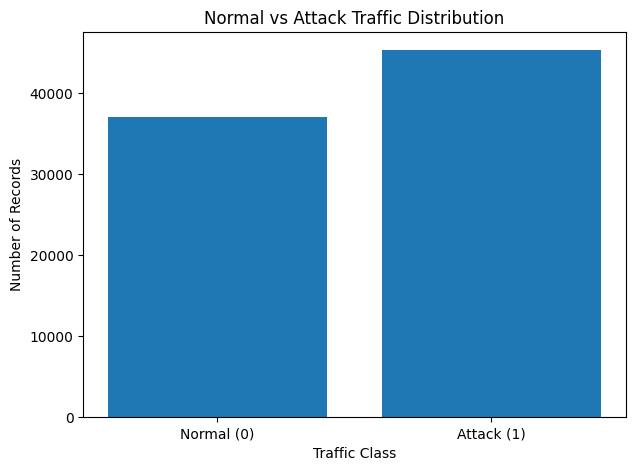

In [4]:
import matplotlib.pyplot as plt

target_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["Normal (0)", "Attack (1)"], target_counts.values)
plt.title("Normal vs Attack Traffic Distribution")
plt.xlabel("Traffic Class")
plt.ylabel("Number of Records")
plt.show()

In [5]:
attack_counts = df["attack_cat"].value_counts()

print("Attack Category Distribution:")
print(attack_counts)

print("\nAttack Category Percentage:")
print((attack_counts / len(df) * 100).round(2))

Attack Category Distribution:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

Attack Category Percentage:
attack_cat
Normal            44.94
Generic           22.92
Exploits          13.52
Fuzzers            7.36
DoS                4.97
Reconnaissance     4.25
Analysis           0.82
Backdoor           0.71
Shellcode          0.46
Worms              0.05
Name: count, dtype: float64


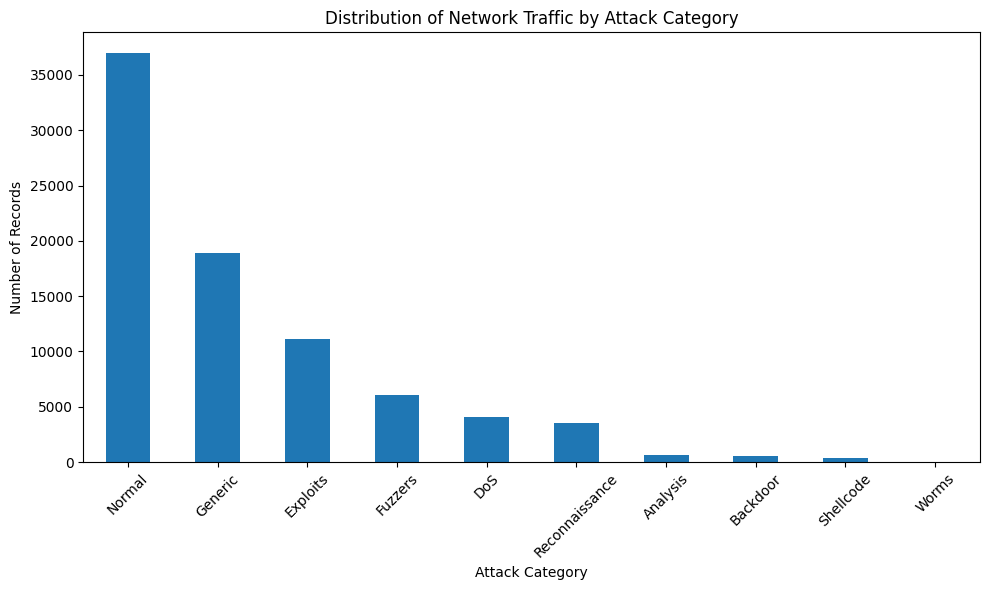

In [6]:
plt.figure(figsize=(10, 6))

attack_counts.sort_values(ascending=False).plot(kind="bar")

plt.title("Distribution of Network Traffic by Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
numerical_df = df.select_dtypes(include=["int64", "float64"])

stats = numerical_df.describe().T

stats["missing"] = numerical_df.isnull().sum()
stats["unique"] = numerical_df.nunique()

display(stats)

,count,mean,std,min,25%,50%,75%,max,missing,unique
id,82332.0,4.116650e+04,2.376735e+04,1.0,20583.750000,4.116650e+04,6.174925e+04,8.233200e+04,0,82332
dur,82332.0,1.006756e+00,4.710444e+00,0.0,0.000008,1.413800e-02,7.193603e-01,5.999999e+01,0,39888
spkts,82332.0,1.866647e+01,1.339164e+02,1.0,2.000000,6.000000e+00,1.200000e+01,1.064600e+04,0,420
dpkts,82332.0,1.754594e+01,1.155741e+02,0.0,0.000000,2.000000e+00,1.000000e+01,1.101800e+04,0,436
sbytes,82332.0,7.993908e+03,1.716423e+05,24.0,114.000000,5.340000e+02,1.280000e+03,1.435577e+07,0,4489
dbytes,82332.0,1.323379e+04,1.514715e+05,0.0,0.000000,1.780000e+02,9.560000e+02,1.465753e+07,0,4034
rate,82332.0,8.241089e+04,1.486204e+05,0.0,28.606114,2.650177e+03,1.111111e+05,1.000000e+06,0,40616
sttl,82332.0,1.809677e+02,1.015134e+02,0.0,62.000000,2.540000e+02,2.540000e+02,2.550000e+02,0,11
dttl,82332.0,9.571300e+01,1.166677e+02,0.0,0.000000,2.900000e+01,2.520000e+02,2.530000e+02,0,8
sload,82332.0,6.454902e+07,1.798618e+08,0.0,11202.466797,5.770032e+05,6.514286e+07,5.268000e+09,0,42873


In [9]:
categorical_features = ["proto", "service", "state"]

for column in categorical_features:
    print("\n" + "=" * 50)
    print("Feature:", column)
    print("Unique Values:", df[column].nunique())
    print("\nTop Categories:")
    print(df[column].value_counts().head(10))


Feature: proto
Unique Values: 131

Top Categories:
proto
tcp     43095
udp     29418
unas     3515
arp       987
ospf      676
sctp      324
any        96
gre        88
rsvp       64
ipv6       61
Name: count, dtype: int64

Feature: service
Unique Values: 13

Top Categories:
service
-           47153
dns         21367
http         8287
smtp         1851
ftp          1552
ftp-data     1396
pop3          423
ssh           204
ssl            30
snmp           29
Name: count, dtype: int64

Feature: state
Unique Values: 7

Top Categories:
state
FIN    39339
INT    34163
CON     6982
REQ     1842
ACC        4
RST        1
CLO        1
Name: count, dtype: int64


In [10]:
X = df.drop(columns=["id", "attack_cat", "label"])
y = df["label"]

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Total Input Features:", X.shape[1])
print("Numerical Features:", len(numerical_features))
print("Categorical Features:", len(categorical_features))

print("\nCategorical Features:")
print(categorical_features)

print("\nExcluded Features:")
print(["id", "attack_cat"])

Total Input Features: 42
Numerical Features: 39
Categorical Features: 3

Categorical Features:
['proto', 'service', 'state']

Excluded Features:
['id', 'attack_cat']


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_transformed = preprocessor.fit_transform(X)

print("Original Feature Count:", X.shape[1])
print("Transformed Feature Count:", X_transformed.shape[1])
print("Transformed Data Shape:", X_transformed.shape)

Original Feature Count: 42
Transformed Feature Count: 190
Transformed Data Shape: (82332, 190)


In [12]:
performance_comparison = pd.DataFrame({
    "Stage": [
        "Week 3 - Model Implementation",
        "Week 4 - Model Evaluation",
        "Week 5 - Baseline Optimization"
    ],
    "Accuracy": [0.9769, 0.9763, 0.9752],
    "Precision": [0.9840, 0.9844, 0.9830],
    "Recall": [0.9739, 0.9724, 0.9718],
    "F1-Score": [0.9789, 0.9784, 0.9774],
    "ROC-AUC": [None, 0.9971, 0.9971]
})

display(performance_comparison)

,Stage,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Week 3 - Model Implementation,0.9769,0.9840,0.9739,0.9789,NaN
1,Week 4 - Model Evaluation,0.9763,0.9844,0.9724,0.9784,0.9971
2,Week 5 - Baseline Optimization,0.9752,0.9830,0.9718,0.9774,0.9971


In [13]:
optimization_results = pd.DataFrame({
    "Configuration": [
        "Baseline",
        "Experiment 1",
        "Experiment 2",
        "Experiment 3",
        "Experiment 4"
    ],
    "Validation F1-Score": [
        0.9774,
        0.9707,
        0.9788,
        0.9790,
        0.9780
    ]
})

display(optimization_results)

,Configuration,Validation F1-Score
0,Baseline,0.9774
1,Experiment 1,0.9707
2,Experiment 2,0.9788
3,Experiment 3,0.9790
4,Experiment 4,0.9780


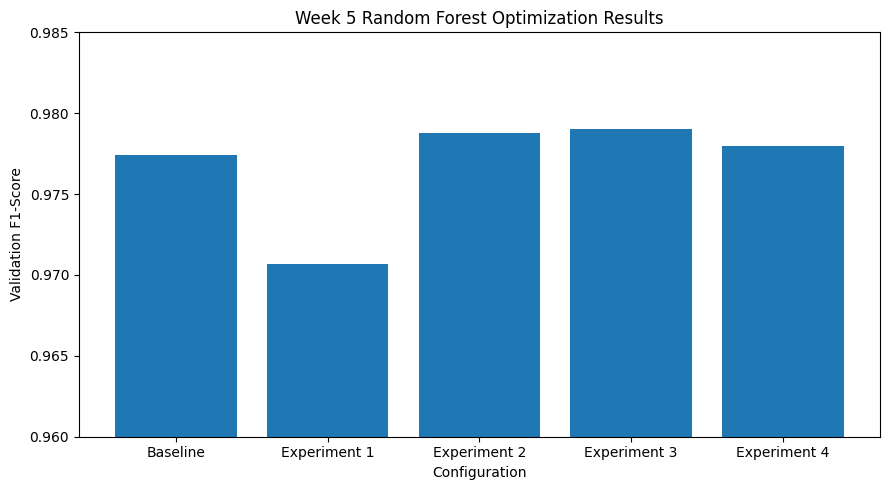

In [14]:
plt.figure(figsize=(9, 5))

plt.bar(
    optimization_results["Configuration"],
    optimization_results["Validation F1-Score"]
)

plt.title("Week 5 Random Forest Optimization Results")
plt.xlabel("Configuration")
plt.ylabel("Validation F1-Score")
plt.ylim(0.96, 0.985)
plt.tight_layout()
plt.show()

In [15]:
best_config = {
    "n_estimators": 150,
    "max_depth": 20,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": "sqrt"
}

print("Best Configuration: Experiment 3")
for parameter, value in best_config.items():
    print(parameter, "=", value)

print("\nBest Validation F1-Score:", 0.9790)
print("Baseline Validation F1-Score:", 0.9774)
print("Improvement:", round(0.9790 - 0.9774, 4))

Best Configuration: Experiment 3
n_estimators = 150
max_depth = 20
min_samples_split = 2
min_samples_leaf = 1
max_features = sqrt

Best Validation F1-Score: 0.979
Baseline Validation F1-Score: 0.9774
Improvement: 0.0016


In [16]:
evaluation_results = {
    "Accuracy": 0.976316,
    "Precision": 0.984370,
    "Recall": 0.972427,
    "F1-Score": 0.978362,
    "ROC-AUC": 0.997125,
    "CV Mean F1": 0.979341,
    "CV F1 Std": 0.000730
}

evaluation_table = pd.DataFrame(
    evaluation_results.items(),
    columns=["Metric", "Value"]
)

display(evaluation_table)

,Metric,Value
0,Accuracy,0.976316
1,Precision,0.984370
2,Recall,0.972427
3,F1-Score,0.978362
4,ROC-AUC,0.997125
5,CV Mean F1,0.979341
6,CV F1 Std,0.000730


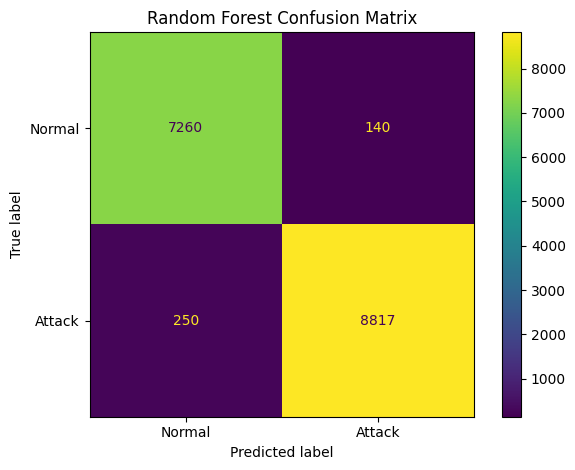

In [18]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = np.array([
    [7260, 140],
    [250, 8817]
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [19]:
tn, fp, fn, tp = 7260, 140, 250, 8817

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("False Positive Rate:", round(fpr, 4))
print("False Negative Rate:", round(fnr, 4))

print("\nFalse Positive Percentage:", round(fpr * 100, 2), "%")
print("False Negative Percentage:", round(fnr * 100, 2), "%")

False Positive Rate: 0.0189
False Negative Rate: 0.0276

False Positive Percentage: 1.89 %
False Negative Percentage: 2.76 %


In [20]:
cv_scores = [0.97832714, 0.97910879, 0.97892583, 0.98005098, 0.98029448]

cv_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "F1-Score": cv_scores
})

display(cv_results)

print("Mean F1-Score:", round(sum(cv_scores) / len(cv_scores), 4))
print("Standard Deviation:", round(pd.Series(cv_scores).std(), 4))

,Fold,F1-Score
0,1,0.978327
1,2,0.979109
2,3,0.978926
3,4,0.980051
4,5,0.980294


Mean F1-Score: 0.9793
Standard Deviation: 0.0008


In [21]:
training_accuracy = 1.0000
testing_accuracy = 0.976316

accuracy_difference = training_accuracy - testing_accuracy

print("Training Accuracy:", training_accuracy)
print("Testing Accuracy:", testing_accuracy)
print("Accuracy Difference:", round(accuracy_difference, 4))
print("Accuracy Difference (%):", round(accuracy_difference * 100, 2), "%")

Training Accuracy: 1.0
Testing Accuracy: 0.976316
Accuracy Difference: 0.0237
Accuracy Difference (%): 2.37 %


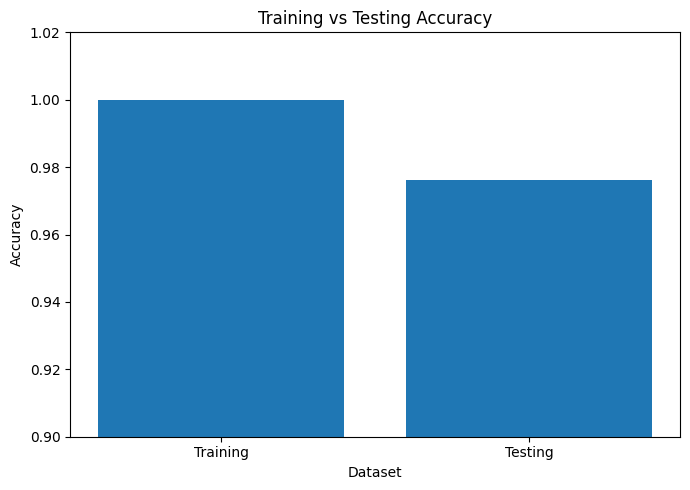

In [22]:
accuracy_comparison = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Accuracy": [1.0000, 0.976316]
})

plt.figure(figsize=(7, 5))
plt.bar(accuracy_comparison["Dataset"], accuracy_comparison["Accuracy"])

plt.title("Training vs Testing Accuracy")
plt.xlabel("Dataset")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.02)
plt.tight_layout()
plt.show()

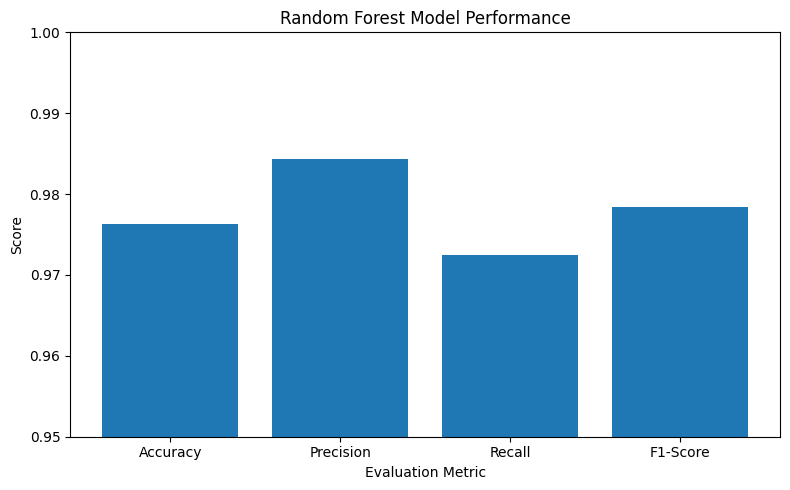

In [23]:
metrics_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [0.976316, 0.984370, 0.972427, 0.978362]
})

plt.figure(figsize=(8, 5))
plt.bar(metrics_comparison["Metric"], metrics_comparison["Score"])

plt.title("Random Forest Model Performance")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0.95, 1.00)
plt.tight_layout()
plt.show()

In [24]:
import os

os.makedirs("Week6_Figures", exist_ok=True)

plt.figure(figsize=(7, 5))
plt.bar(["Normal (0)", "Attack (1)"], target_counts.values)
plt.title("Normal vs Attack Traffic Distribution")
plt.xlabel("Traffic Class")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.savefig("Week6_Figures/target_distribution.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(10, 6))
attack_counts.sort_values(ascending=False).plot(kind="bar")
plt.title("Distribution of Network Traffic by Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Week6_Figures/attack_category_distribution.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(9, 5))
plt.bar(
    optimization_results["Configuration"],
    optimization_results["Validation F1-Score"]
)
plt.title("Week 5 Random Forest Optimization Results")
plt.xlabel("Configuration")
plt.ylabel("Validation F1-Score")
plt.ylim(0.96, 0.985)
plt.tight_layout()
plt.savefig("Week6_Figures/optimization_results.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(7, 5))
plt.bar(["Training", "Testing"], [1.0000, 0.976316])
plt.title("Training vs Testing Accuracy")
plt.xlabel("Dataset")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.02)
plt.tight_layout()
plt.savefig("Week6_Figures/training_testing_accuracy.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(8, 5))
plt.bar(
    ["Accuracy", "Precision", "Recall", "F1-Score"],
    [0.976316, 0.984370, 0.972427, 0.978362]
)
plt.title("Random Forest Model Performance")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0.95, 1.00)
plt.tight_layout()
plt.savefig("Week6_Figures/model_performance.png", dpi=300, bbox_inches="tight")
plt.close()

print("All Week 6 figures saved successfully.")
print("Folder: Week6_Figures")

All Week 6 figures saved successfully.
Folder: Week6_Figures


In [25]:
final_results = pd.DataFrame({
    "Evaluation Area": [
        "Dataset Records",
        "Original Features",
        "Input Features",
        "Transformed Features",
        "Missing Values",
        "Duplicate Rows",
        "Attack Records",
        "Normal Records",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1-Score",
        "Test ROC-AUC",
        "5-Fold Mean F1",
        "5-Fold F1 Std",
        "False Positive Rate",
        "False Negative Rate",
        "Best Validation F1"
    ],
    "Result": [
        "82,332",
        "45",
        "42",
        "190",
        "0",
        "0",
        "45,332 (55.06%)",
        "37,000 (44.94%)",
        "97.63%",
        "98.44%",
        "97.24%",
        "97.84%",
        "99.71%",
        "97.93%",
        "0.08%",
        "1.89%",
        "2.76%",
        "97.90%"
    ]
})

display(final_results)

,Evaluation Area,Result
0,Dataset Records,"82,332"
1,Original Features,45
2,Input Features,42
3,Transformed Features,190
4,Missing Values,0
5,Duplicate Rows,0
6,Attack Records,"45,332 (55.06%)"
7,Normal Records,"37,000 (44.94%)"
8,Test Accuracy,97.63%
9,Test Precision,98.44%


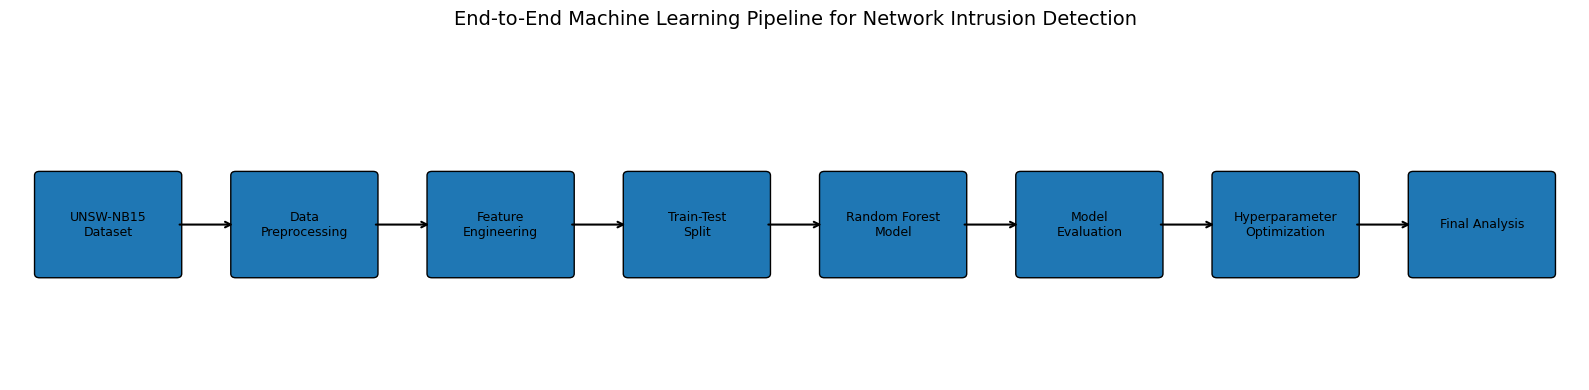

In [26]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

steps = [
    "UNSW-NB15\nDataset",
    "Data\nPreprocessing",
    "Feature\nEngineering",
    "Train-Test\nSplit",
    "Random Forest\nModel",
    "Model\nEvaluation",
    "Hyperparameter\nOptimization",
    "Final Analysis"
]

fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 16)
ax.set_ylim(0, 4)
ax.axis("off")

x_positions = [0.3, 2.3, 4.3, 6.3, 8.3, 10.3, 12.3, 14.3]

for i, (step, x) in enumerate(zip(steps, x_positions)):
    box = FancyBboxPatch(
        (x, 1.3),
        1.4,
        1.2,
        boxstyle="round,pad=0.05"
    )
    ax.add_patch(box)
    ax.text(
        x + 0.7,
        1.9,
        step,
        ha="center",
        va="center",
        fontsize=9
    )

    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x + 2.0, 1.9),
            xytext=(x + 1.4, 1.9),
            arrowprops=dict(arrowstyle="->", lw=1.5)
        )

ax.set_title(
    "End-to-End Machine Learning Pipeline for Network Intrusion Detection",
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.savefig(
    "Week6_Figures/ml_pipeline_diagram.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

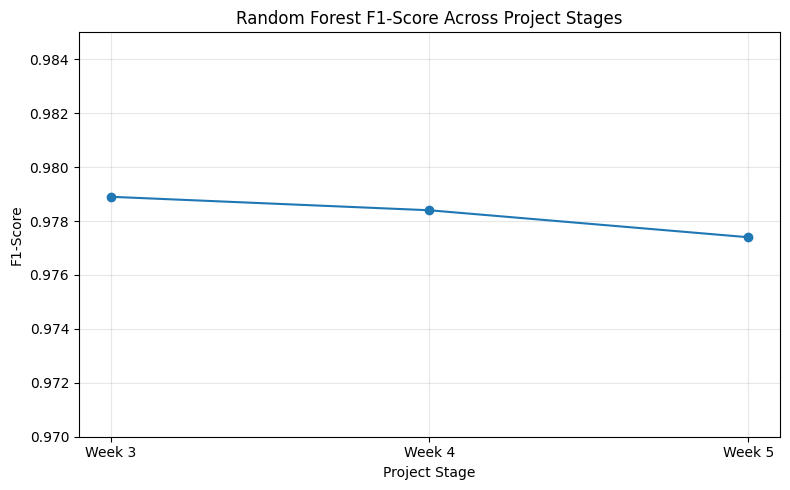

In [27]:
stage_results = pd.DataFrame({
    "Stage": [
        "Week 3",
        "Week 4",
        "Week 5"
    ],
    "F1-Score": [
        0.9789,
        0.9784,
        0.9774
    ]
})

plt.figure(figsize=(8, 5))
plt.plot(
    stage_results["Stage"],
    stage_results["F1-Score"],
    marker="o"
)

plt.title("Random Forest F1-Score Across Project Stages")
plt.xlabel("Project Stage")
plt.ylabel("F1-Score")
plt.ylim(0.97, 0.985)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "Week6_Figures/stage_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

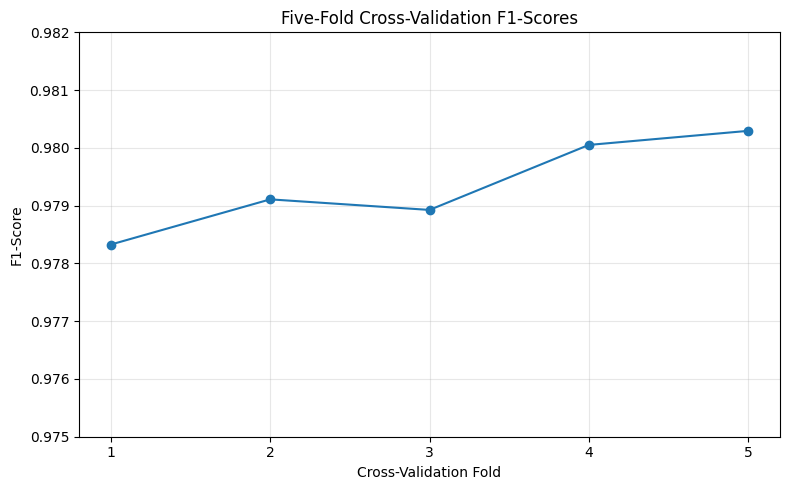

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    cv_results["Fold"],
    cv_results["F1-Score"],
    marker="o"
)

plt.title("Five-Fold Cross-Validation F1-Scores")
plt.xlabel("Cross-Validation Fold")
plt.ylabel("F1-Score")
plt.ylim(0.975, 0.982)
plt.xticks([1, 2, 3, 4, 5])
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "Week6_Figures/cross_validation_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()